In [ ]:
# Данный python-скрипт имитирует запрос к БД
# Напишите ваш SQL-запрос в query и запустите данный python-скрипт для получения результата
# Перед запуском скрипта установите библиотеку duckdb

# Установка библиотеки duckdb
# pip install duckdb duckdb-engine

# Импорт библиотек
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import duckdb

# Задание таблиц БД
users = pd.read_csv('users.csv')
course_users = pd.read_csv('course_users.csv')
courses = pd.read_csv('courses.csv')
course_types = pd.read_csv('course_types.csv')
lessons = pd.read_csv('lessons.csv')
subjects = pd.read_csv('subjects.csv')
cities = pd.read_csv('cities.csv')
homework_done = pd.read_csv('homework_done.csv')
homework = pd.read_csv('homework.csv')
homework_lessons = pd.read_csv('homework_lessons.csv')
user_roles = pd.read_csv('user_roles.csv') 

In [5]:
sql_query = """
SELECT 
    c.id AS course_id,
    c.name AS course_name,
    s.name AS subject_name,
    ct.name AS course_type,
    c.starts_at::DATE AS course_start_date,
    u.id AS student_id,
    u.last_name AS student_last_name,
    ci.name AS student_city,
    cu.active AS is_active_student,
    cu.created_at::DATE AS course_signup_date,
    
    -- Количество месяцев и недель с момента старта курса, месяцы для удобства
    date_diff('month', c.starts_at::DATE, current_date) AS course_duration_months,
    date_diff('week', c.starts_at::DATE, current_date) AS course_duration_weeks,
  
    
    -- Количество недель с момента зачисления
    date_diff('week', cu.created_at::DATE, current_date) AS weeks_signup,
    
    -- Количество выполненых дз
    (SELECT COUNT(*) 
     FROM homework_done hd
     JOIN homework_lessons hl ON hd.homework_id = hl.homework_id
     JOIN lessons l ON hl.lesson_id = l.id
     WHERE hd.user_id = u.id AND l.course_id = c.id) AS completed_homeworks_count

FROM users u
JOIN course_users cu ON u.id = cu.user_id
JOIN courses c ON cu.course_id = c.id
JOIN course_types ct ON c.course_type_id = ct.id
JOIN subjects s ON c.subject_id = s.id
JOIN cities ci ON u.city_id = ci.id

WHERE u.user_role_id = 5                   -- Студенты
AND ct.name IN ('Годовой', 'Годовой 2.0')  -- Годовые курсы в явном виде
AND date_diff('week', c.starts_at::DATE, current_date) BETWEEN 0 AND 48 -- Курс длится от 1 до 12 месяцев, с учетом дальнейшего использованя недель

ORDER BY 
    course_duration_weeks DESC,
    c.id, 
    u.last_name;
"""

In [6]:
# Выполнение SQL-запроса
df_result = duckdb.query(sql_query).to_df()

# Вывод результата
display(df_result)

,course_id,course_name,subject_name,course_type,course_start_date,student_id,student_last_name,student_city,is_active_student,course_signup_date,course_duration_months,course_duration_weeks,weeks_signup,completed_homeworks_count
0,16,Годовой 2к25 стандарт,Обществознание,Годовой,2024-09-16,28773,Akhmedova,Москва,1,2024-09-26,7,30,28,12
1,16,Годовой 2к25 стандарт,Обществознание,Годовой,2024-09-16,28938,Aleshina,Москва,1,2024-09-27,7,30,28,17
2,16,Годовой 2к25 стандарт,Обществознание,Годовой,2024-09-16,10127,Alexandrova,Псков,1,2024-07-28,7,30,37,5
3,16,Годовой 2к25 стандарт,Обществознание,Годовой,2024-09-16,25044,Alone,Москва,1,2024-09-16,7,30,30,14
4,16,Годовой 2к25 стандарт,Обществознание,Годовой,2024-09-16,10255,Andre,Москва,1,2024-07-29,7,30,37,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5535,103,Погоня за мечтой 2к25,Математика (база),Годовой 2.0,2024-11-19,10589,Айзенов,Калуга,1,2024-11-07,5,20,22,0
5536,103,Погоня за мечтой 2к25,Математика (база),Годовой 2.0,2024-11-19,30062,Гималдинова,Канаш,1,2024-11-08,5,20,22,0
5537,103,Погоня за мечтой 2к25,Математика (база),Годовой 2.0,2024-11-19,25151,Иванова,Йошкар-Ола,1,2024-11-05,5,20,22,0
5538,103,Погоня за мечтой 2к25,Математика (база),Годовой 2.0,2024-11-19,10203,Московкина,Москва,1,2024-11-10,5,20,22,0


In [7]:
# Количество дубликатов
print(df_result.duplicated().sum())

0


In [8]:
# Типы данных
print(df_result.dtypes)

course_id                             int64
course_name                          object
subject_name                         object
course_type                          object
course_start_date            datetime64[us]
student_id                            int64
student_last_name                    object
student_city                         object
is_active_student                     int64
course_signup_date           datetime64[us]
course_duration_months                int64
course_duration_weeks                 int64
weeks_signup                          int64
completed_homeworks_count             int64
dtype: object


In [11]:
# Пропуски в данных
print(df_result.isnull().sum())

course_id                    0
course_name                  0
subject_name                 0
course_type                  0
course_start_date            0
student_id                   0
student_last_name            0
student_city                 0
is_active_student            0
course_signup_date           0
course_duration_months       0
course_duration_weeks        0
weeks_signup                 0
completed_homeworks_count    0
dtype: int64


In [18]:
#print( df_result['course_start_date'].value_counts().sort_index() )
#print( df_result['course_signup_date'].value_counts().sort_index() )
#print( df_result['course_duration_months'].value_counts().sort_index() )
#print( df_result['weeks_signup'].value_counts().sort_index() )
#print( df_result['student_city'].value_counts().sort_values(ascending=0) )

# Числовые значения > 0
for each in ['course_id', 'student_id', 'is_active_student', 'course_duration_months', 'course_duration_weeks', 'weeks_signup', 'completed_homeworks_count']:
    print((df_result[each]> 0).all(), ' | ', each)

True  |  course_id
True  |  student_id
False  |  is_active_student
True  |  course_duration_months
True  |  course_duration_weeks
True  |  weeks_signup
False  |  completed_homeworks_count


In [25]:
# Количество выполненых заданий не строго > 0, но это нормально
print( df_result['completed_homeworks_count'].min(), '-', df_result['completed_homeworks_count'].max() )

0 - 34


In [26]:
# Количество активных  / не отчисленных учеников
print(df_result['is_active_student'].value_counts().sort_index() )

is_active_student
0     315
1    5225
Name: count, dtype: int64


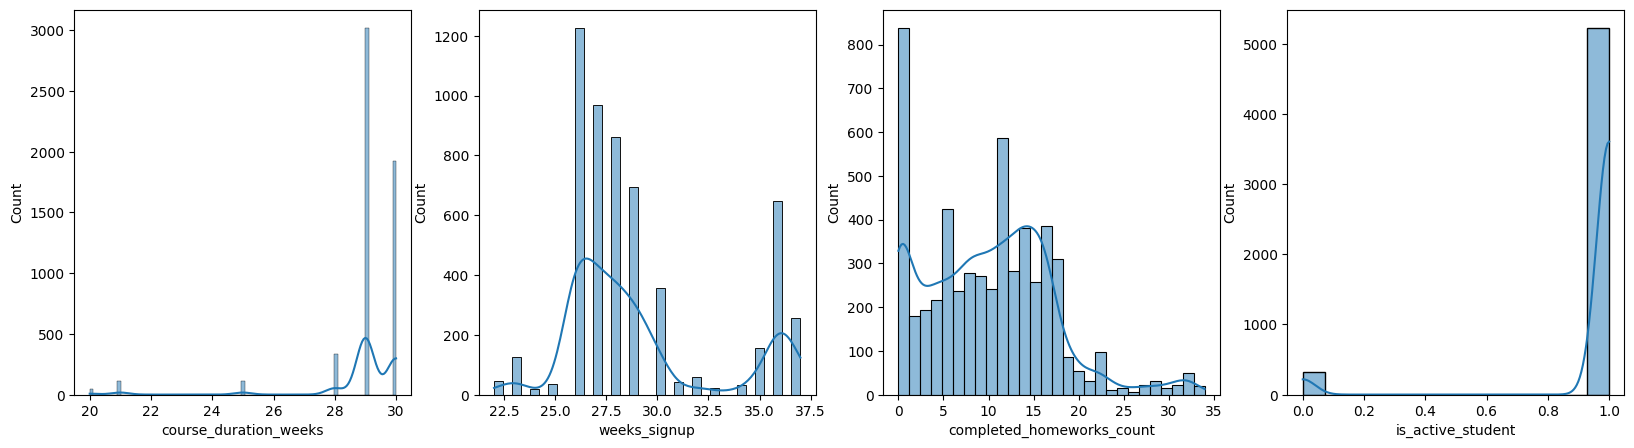

In [ ]:
# Укороченный датасет для визуального анализа экстримальных числовых значений
short_df = df_result[['course_duration_weeks', 'weeks_signup', 'completed_homeworks_count', 'is_active_student']].copy()

#sns.pairplot(short_df, height=3, hue='completed_homeworks_count')

plt.figure(figsize=(20, 5))
counter = 1
for each in short_df.columns:
    plt.subplot(1, 4, counter)
    sns.histplot(data=short_df, x=each, kde=True)
    counter += 1

In [35]:
# 2. Разделение на волны
def waves(date):
    delta = (date['course_signup_date'] - date['course_start_date']).days
    if delta <= 0:
        return 0  # Волна 0
    elif delta <= 7:
        return 1  # Волна 1
    elif delta <= 14:
        return 2  # Волна 2
    elif delta <= 21:
        return 3  # Волна 3
    elif delta <= 28:
        return 4  # Волна 4
    else:
        return 5  # Волна 5

df_result['wave'] = df_result.apply(waves, axis=1)

# Анализ распределения по волнам
print( df_result['wave'].value_counts().sort_index() )

wave
0    2208
1     764
2     900
3     899
4     744
5      25
Name: count, dtype: int64


In [41]:
# Дополнительный анализ по волнам
wave_analysis = df_result.groupby('is_active_student').agg({
    'student_id': 'count',
    'completed_homeworks_count': 'mean',
    'course_duration_months': 'mean'
})

print(wave_analysis)

                   student_id  completed_homeworks_count  \
is_active_student                                          
0                         315                   1.307937   
1                        5225                  10.524211   

                   course_duration_months  
is_active_student                          
0                                6.873016  
1                                6.927656  


In [42]:
# Сохранение результата
df_result.to_csv('students_with_waves.csv', index=False)